In [116]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os, time
from tqdm.auto import tqdm
import torch

pd.set_option("display.max_columns", None)        # toutes les colonnes
pd.set_option("display.max_colwidth", None)       # texte complet dans les cellules
pd.set_option("display.width", 0)                 # auto (évite le wrap bizarre)
pd.set_option("display.max_rows", 200)  

In [117]:
df = pd.read_excel("data/nicollin_accidents.xlsx", skiprows =4)

In [118]:
df.shape

(5886, 11)

In [119]:
df

,Nom du Collaborateur,Date,Heure,Type,Infos*,Centre,Circonstances détaillées,Lésions,Jours,IPP,Taux
0,SPANIOL THIERRY,16/01/2021,10:00,AT,A,10\n10\nAMNEVILLE,Le salarié s'est baissé pour ramasser des déchets tombés au sol.\nLe salarié déclare que le lève conteneur est retombé tout seul et l'aurait blessé à la tête.\nlève conteneur,"1) Plaie ouverte (y compris coupure, lacération, plaie punctiforme avec corps étranger pénétrant, morsure d'animal)\n ----> Tête",1.0,NON,0.0
1,CARRIZO SYLVIE,11/06/2012,08:30,AT,A,1001\nCENTRE CASTELNAU ADMINIS\n1974 avenue Henri Wallon,"D'après les dires de la salariée, elle aurait trébuché sur le banc dans le local du personnel, en sortant des toilettes. elle aurait perdu l'équilibre et se serait tordu la cheville droite et le poignet droit.\n\n",1) Entorse et foulure\n ----> Cheville (Coté Droit)\n2) Entorse et foulure\n ----> Poignet (Coté Droit),81.0,NON,0.0
2,PUCHOL ROBERT,21/04/2022,15:00,AT,NaN,1004\nCENTRE SIEGE JEUNE PARQUE\nMas du Domaine Saint Gabriel,"Le salarié effectuait la maintenance d'un véhicule 4*4.\nLe salarié déclare qu'en descendait du plateau du véhicule, il aurait chuté.\nSol","1) Douleur\n ----> Jambe, y compris genou (Coté Gauche)",0.0,NON,0.0
3,GEAY XAVIER,08/02/2022,10:03,SD,NaN,1004\nCENTRE SIEGE JEUNE PARQUE\n,\n\n,NaN,0.0,NON,0.0
4,GELIS NELLY,05/10/2021,11:00,SD,NaN,1004\nCENTRE SIEGE JEUNE PARQUE\n,\n\n,NaN,0.0,NON,0.0
...,...,...,...,...,...,...,...,...,...,...,...
5881,BRESSON THIERRY,14/09/2015,09:15,AT,A,9602\nCENTRE DU VIGAN ASSAINISS\nStation d'épuration du Vigan,"D'après les dires de la victime, il aurait glissé en descendant de la passerelle tournante du bassin clarificateur. Son pied a glissée de la plaque de fer mouillée par les intempéries et en se retenant, son corps a pris un choc sur le bord en fer.\n\n",1) Lésion traumatique superficielle et plaie ouverte\n ----> Hanche et articulation,15.0,NON,0.0
5882,GUELAI SELIM,18/02/2014,09:30,AT,A,9602\nCENTRE DU VIGAN ASSAINISS\nstep du Vigan,"D'apres la vicitime il aurait voulu déplacer un caillou du chemin afin de pouvoir acceder a la station d'epuration avec son véhicule et il aurait ressenti une douleur vive dans le dos, au moment de soulever le caillou.\n\n","1) Douleur\n ----> Dos, y compris colonne vertébrale et vertèbres dorsales",12.0,NON,0.0
5883,GUELAI SELIM,15/05/2012,11:30,AT,A,9602\nCENTRE DU VIGAN ASSAINISS\nchez le client well,d'apres la victime en remontant d'une fosse il aurait glissé a l'echelle et sa tete aurait heurté la rambarde. Il se serait ouvert l'arcade sourcilliere droite et se serait fait mal au dos.\n\n,"1) Plaie ouverte (y compris coupure, lacération, plaie punctiforme avec corps étranger pénétrant, morsure d'animal)\n ----> Oeil (Coté Droit)\n2) Douleur\n ----> Dos, y compris colonne vertébrale et vertèbres dorsales (Coté Droit)",13.0,NON,0.0
5884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
df["Circonstances détaillées"] = df["Circonstances détaillées"].replace(
    r"^(?:\s|\\n|\\r|\\t)*$",
    np.nan,
    regex=True
)

In [121]:
df["accident_id"] = list(range(0, len(df)))
df["accident_summary"]= df["Circonstances détaillées"]

In [122]:
df.columns

Index(['Nom du Collaborateur', 'Date', 'Heure', 'Type', 'Infos*', 'Centre',
       'Circonstances détaillées', 'Lésions', 'Jours', 'IPP', 'Taux',
       'accident_id', 'accident_summary'],
      dtype='object')

In [123]:
df = df.dropna(subset="accident_summary",axis=0)

In [124]:
df.shape

(5682, 13)

# with SAT (Segment any Text)

In [125]:
#pip install wtpsplit

In [126]:
from wtpsplit import SaT

In [127]:
sat = SaT("sat-12l-sm")
sat.split?

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Signature:
sat.split(
    text_or_texts,
    threshold: 'float' = None,
    stride=64,
    block_size: 'int' = 512,
    batch_size=32,
    pad_last_batch: 'bool' = False,
    weighting: "Literal['uniform', 'hat']" = 'uniform',
    remove_whitespace_before_inference: 'bool' = False,
    outer_batch_size=1000,
    paragraph_threshold: 'float' = 0.5,
    strip_whitespace: 'bool' = False,
    do_paragraph_segmentation: 'bool' = False,
    split_on_input_newlines: 'bool' = True,
    treat_newline_as_space=None,
    verbose: 'bool' = False,
    min_length: 'int' = 1,
    max_length: 'int' = None,
    prior_type: 'str' = 'uniform',
    prior_kwargs: 'dict' = None,
    algorithm: 'str' = 'viterbi',
)
Docstring: <no docstring>
File:      c:\users\aho\documents\analysis factor project\safer\text\.venv\lib\site-packages\wtpsplit\__init__.py
Type:      method

In [128]:
from tqdm.auto import tqdm

def segment_to_facts_with_progress(
    df_btp: pd.DataFrame,
    text_col: str = "accident_summary",
    id_col: str | None = None,
    model_id: str = "sat-6l-sm",
    threshold: float = 0.8,
    stride: int = 128, #128
    block_size: int = 128, #256
    weighting: str = "hat",
    device: str | None = None,   # "cuda" ou "cpu"
    batch_size: int = 256,
    progress: bool = True
) -> pd.DataFrame:

    df = df_btp.copy()

    # 1) ID accident
    if id_col is None:
        df = df.reset_index(drop=False).rename(columns={"index": "accident_id"})
        id_col = "accident_id"
    else:
        if id_col not in df.columns:
            raise ValueError(f"'{id_col}' n'existe pas dans df_btp.")

    # 2) Modèle
    sat = SaT(model_id)

    # GPU (comme dans la doc) : IMPORTANT -> pas de réaffectation
    if device is not None and str(device).startswith("cuda"):
        sat.half().to("cuda")     # <- pas de "sat = ..."
    elif device is not None:
        sat.to(device)            # <- pas de "sat = ..."

    base_kwargs = dict(
        threshold=threshold,
        stride=stride,
        block_size=block_size,
        weighting=weighting,
        algorithm="viterbi"
    )

    # 3) split robuste (API newline varie selon versions)
    def split_batch(texts):
        try:
            return list(sat.split(texts, split_on_input_newlines=False, **base_kwargs))
        except TypeError:
            return list(sat.split(texts, treat_newline_as_space=False, **base_kwargs))

    # 4) Traitement par lots + suivi
    texts = df[text_col].fillna("").astype(str).tolist()
    n = len(texts)

    segments_per_doc = []
    iterator = range(0, n, batch_size)
    if progress:
        iterator = tqdm(iterator, total=(n + batch_size - 1)//batch_size, desc="Segmentation SaT (batches)")

    t0 = time.time()
    for start in iterator:
        batch = texts[start:start + batch_size]
        batch_segs = split_batch(batch)      # <- liste de listes
        segments_per_doc.extend(batch_segs)

        if progress and hasattr(iterator, "set_postfix"):
            avg_segs = sum(len(x) for x in batch_segs) / max(1, len(batch_segs))
            iterator.set_postfix(avg_segments=f"{avg_segs:.2f}")

    if progress:
        print(f"Terminé en {time.time() - t0:.1f}s — {n} récits segmentés.")

    # 5) Format long + fact_id (1..N par accident)
    out = df.assign(fact_text=segments_per_doc).explode("fact_text", ignore_index=True)
    out["fact_text"] = out["fact_text"].astype(str).str.strip()
    out = out[out["fact_text"].ne("")]

    out["fact_id"] = range(1, len(out) + 1)

    ordered_cols = [id_col, "fact_id", "fact_text"] + [c for c in df.columns if c != id_col]
    return out[ordered_cols]

In [129]:
import torch

In [130]:
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda version:", torch.version.cuda)
print("cudnn:", torch.backends.cudnn.version())

if torch.cuda.is_available():
    n = torch.cuda.device_count()
    print("nb GPUs:", n)

    for i in range(n):
        prop = torch.cuda.get_device_properties(i)
        print(f"\n--- GPU {i} ---")
        print("name:", prop.name)
        print("total memory (GB):", round(prop.total_memory / 1024**3, 2))
        print("compute capability:", f"{prop.major}.{prop.minor}")
        print("multi processors:", prop.multi_processor_count)

        # Mémoire libre / totale (si supporté par ta version)
        try:
            free, total = torch.cuda.mem_get_info(i)
            print("free memory (GB):", round(free / 1024**3, 2))
            print("total memory (GB):", round(total / 1024**3, 2))
        except Exception as e:
            print("mem_get_info not available:", e)


torch: 2.5.1+cu124
cuda available: True
torch cuda version: 12.4
cudnn: 90100
nb GPUs: 1

--- GPU 0 ---
name: NVIDIA GeForce RTX 4090 Laptop GPU
total memory (GB): 15.99
compute capability: 8.9
multi processors: 76
free memory (GB): 13.89
total memory (GB): 15.99


In [131]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
sent_df  = segment_to_facts_with_progress(df,model_id="sat-12l-sm", id_col="accident_id", device=device, batch_size=256, progress=True)

cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Segmentation SaT (batches):   0%|          | 0/23 [00:00<?, ?it/s]

C:\Users\aho\Documents\analysis factor project\SAFER\text\.venv\Lib\site-packages\wtpsplit\__init__.py:1297: UserWarning: split_on_input_newlines=False will lead to newlines in the output if they were present in the input. Within the model, such newlines are treated as spaces. If you want to split on such newlines, set split_on_input_newlines=True.
  warnings.warn(


Terminé en 29.0s — 5682 récits segmentés.


In [132]:
sent_df = sent_df.rename({"fact_text":"sentence"},axis=1)

In [133]:
word_re = r"[A-Za-zÀ-ÖØ-öø-ÿ0-9]+"
sent_df = sent_df.copy()
sent_df["word_count"] = sent_df["sentence"].fillna("").astype(str).str.findall(word_re).str.len()

In [134]:
sent_df.shape

(10383, 16)

## Audit

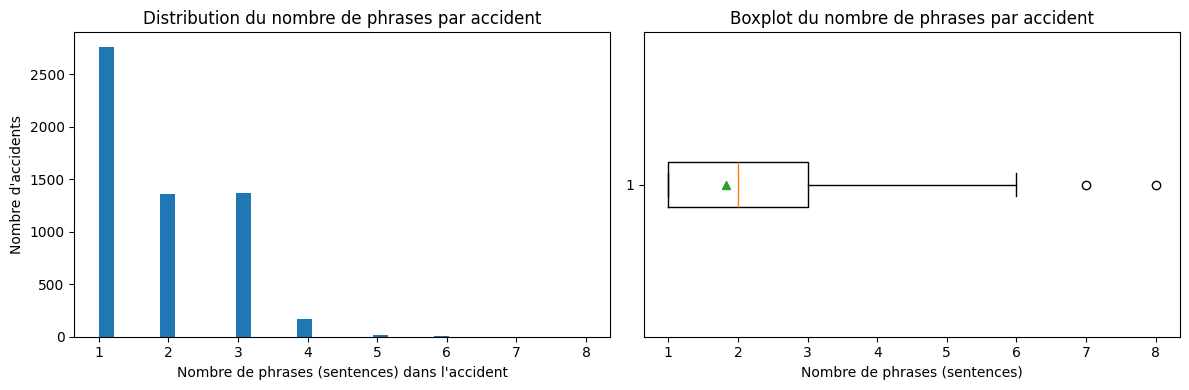

In [135]:
counts = (sent_df.groupby("accident_id")
                 .size()
                 .rename("n_sentences")
                 .reset_index())

x = counts["n_sentences"].to_numpy()

# 2) Plots côte à côte
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme (gauche)
ax[0].hist(x, bins="auto")
ax[0].set_title("Distribution du nombre de phrases par accident")
ax[0].set_xlabel("Nombre de phrases (sentences) dans l'accident")
ax[0].set_ylabel("Nombre d'accidents")

# Boxplot (droite)
ax[1].boxplot(x, vert=False, showmeans=True)
ax[1].set_title("Boxplot du nombre de phrases par accident")
ax[1].set_xlabel("Nombre de phrases (sentences)")

plt.tight_layout()
plt.show()

In [136]:
#counts["n_sentences"].value_counts()

In [137]:
#counts.loc[counts["n_sentences"]==46]

In [138]:
sent_df.shape

(10383, 16)

In [139]:
#sent_df.loc[sent_df["accident_id"]==992]

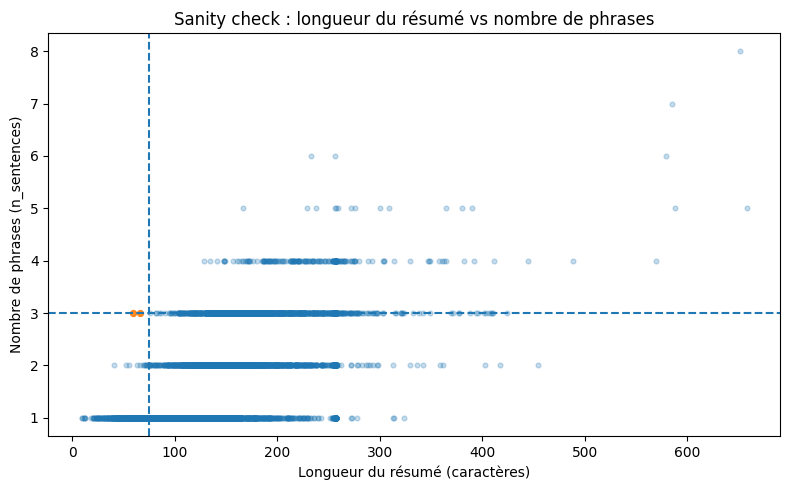

,accident_id,n_sentences,summary_len_chars
5072,5262,3,59
3847,4016,3,66


In [140]:
# 1) Features par accident
acc_feats = (
    sent_df.assign(
        summary_len_chars=sent_df["accident_summary"].fillna("").astype(str).str.len()
    )
    .groupby("accident_id", as_index=False)
    .agg(
        n_sentences=("sentence", "size"),
        summary_len_chars=("summary_len_chars", "first"),  # même valeur pour tout l'accident
    )
)

x = acc_feats["summary_len_chars"].to_numpy()
y = acc_feats["n_sentences"].to_numpy()

# 2) Seuils pour repérer les cas suspects (ajuste si tu veux)
x_thr = np.quantile(x, 0.10)   # accidents les + courts (10%)
y_thr = np.quantile(y, 0.90)   # accidents les + segmentés (10%)

suspect = (x <= x_thr) & (y >= y_thr)

# 3) Scatter + zone suspecte
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.scatter(x[~suspect], y[~suspect], alpha=0.25, s=12)
ax.scatter(x[suspect],  y[suspect],  alpha=0.9,  s=18)

ax.axvline(x_thr, linestyle="--")
ax.axhline(y_thr, linestyle="--")

ax.set_title("Sanity check : longueur du résumé vs nombre de phrases")
ax.set_xlabel("Longueur du résumé (caractères)")
ax.set_ylabel("Nombre de phrases (n_sentences)")

plt.tight_layout()
plt.show()

# 4) Liste des accidents suspects (pour inspection)
suspects_df = acc_feats.loc[suspect].sort_values(["summary_len_chars", "n_sentences"], ascending=[True, False])
suspects_df.head(20)

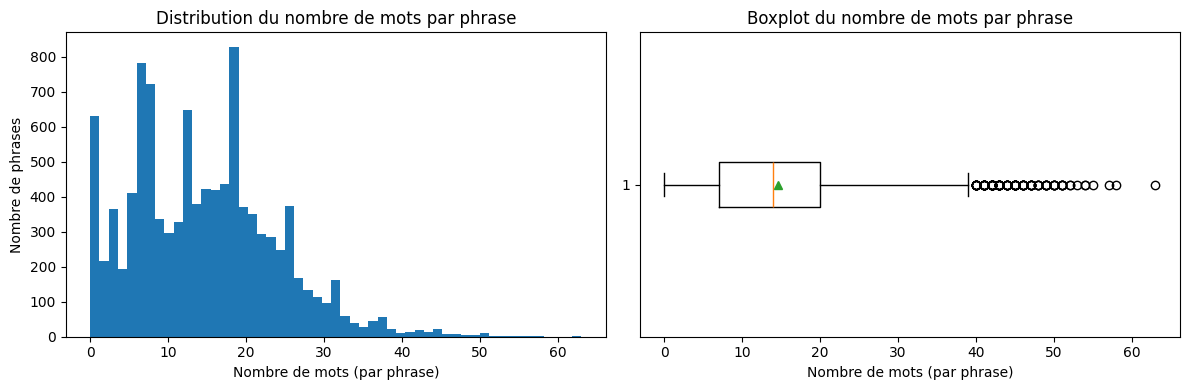

In [141]:
# ------------------------------------------------------------
# 1) Word count par phrase (global)
# ------------------------------------------------------------
x = sent_df["word_count"].to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme
ax[0].hist(x, bins="auto")
ax[0].set_title("Distribution du nombre de mots par phrase")
ax[0].set_xlabel("Nombre de mots (par phrase)")
ax[0].set_ylabel("Nombre de phrases")

# Boxplot
ax[1].boxplot(x, vert=False, showmeans=True)
ax[1].set_title("Boxplot du nombre de mots par phrase")
ax[1].set_xlabel("Nombre de mots (par phrase)")

plt.tight_layout()
plt.show()

In [142]:
long_segs = (
    sent_df.loc[sent_df["word_count"] > 50,
                ["accident_id", "fact_id", "word_count", "sentence"]]
    .sort_values("word_count", ascending=False)
)

little_segs = (sent_df.loc[sent_df["word_count"] ==2,
                ["accident_id", "fact_id", "word_count", "sentence"]]
    .sort_values("word_count", ascending=False)
)

In [143]:
little_segs.shape

(216, 4)

In [144]:
little_segs.head(100)

,accident_id,fact_id,word_count,sentence
2,0,3,2,lève conteneur
7461,4409,7462,2,Véhicule / sol.
7091,4202,7092,2,mini véhicule
7105,4207,7106,2,Lève container
7119,4212,7120,2,bac marchandise
7159,4230,7160,2,Le sol
7196,4242,7197,2,Barre métallique
7208,4247,7209,2,Barre métallique
7224,4252,7225,2,Corps étranger
7228,4253,7229,2,La chute


In [145]:
print("Nb de segments littles :", len(little_segs))

Nb de segments littles : 216


In [146]:
print("Nb de segments > 50 mots :", len(long_segs))

Nb de segments > 50 mots : 14


## Affinage

In [147]:
import re
import unicodedata
import spacy

# --- Normalisation robuste (accents/ponctuation/bullets) pour détecter les headers "seuls" ---
def normalize_header(s: str) -> str:
    s = s.strip().lower()
    # enlever accents
    s = "".join(c for c in unicodedata.normalize("NFKD", s) if not unicodedata.combining(c))
    # remplacer tout ce qui n'est pas lettre/chiffre/espace par espace (retire ":" "-" "•" etc.)
    s = re.sub(r"[^a-z0-9\s]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

sent_df["_norm"] = sent_df["sentence"].map(normalize_header)

# --- 1) Retirer "A noter" / "Causes identifiees" quand la phrase ne contient QUE ça (2 mots) ---
headers_2words = {"a noter", "causes identifiees"}
mask_header_only = (sent_df["word_count"] == 2) & (sent_df["_norm"].isin(headers_2words))

# --- 2) Retirer phrases 1 mot ---
mask_keep = (sent_df["word_count"] != 1) & (~mask_header_only)

# --- 3) Retirer phrases 2-3 mots sans verbe (spaCy POS) ---
nlp = spacy.load("fr_core_news_sm", disable=["ner", "parser"])  # tagger/morph suffisent

def doc_has_verb(doc):
    return any(tok.pos_ in ("VERB", "AUX") for tok in doc)

short_mask = sent_df["word_count"].isin([2]) & mask_keep
short_texts = sent_df.loc[short_mask, "sentence"].tolist()

has_verb_flags = []
for doc in tqdm(nlp.pipe(short_texts, batch_size=256), total=len(short_texts), desc="spaCy POS (2-3 mots)"):
    has_verb_flags.append(doc_has_verb(doc))

sent_df.loc[short_mask, "has_verb"] = has_verb_flags
sent_df["has_verb"] = sent_df["has_verb"].fillna(True)

mask_keep = mask_keep & ~(sent_df["word_count"].isin([2, 3]) & (sent_df["has_verb"] == False))

spaCy POS (2-3 mots):   0%|          | 0/216 [00:00<?, ?it/s]

In [148]:
# --- Résultat ---
sent_df_filtered = sent_df.loc[mask_keep].drop(columns=["has_verb", "_norm"])
sent_df_filtered  = sent_df_filtered.copy()

In [149]:
sent_df_filtered.loc[sent_df_filtered["word_count"] ==1,
                ["accident_id", "fact_id", "word_count", "sentence"]].sort_values("word_count", ascending=False)

,accident_id,fact_id,word_count,sentence


In [150]:
sent_df_filtered.columns

Index(['accident_id', 'fact_id', 'sentence', 'Nom du Collaborateur', 'Date',
       'Heure', 'Type', 'Infos*', 'Centre', 'Circonstances détaillées',
       'Lésions', 'Jours', 'IPP', 'Taux', 'accident_summary', 'word_count'],
      dtype='object')

In [151]:
sent_df_filtered 

,accident_id,fact_id,sentence,Nom du Collaborateur,Date,Heure,Type,Infos*,Centre,Circonstances détaillées,Lésions,Jours,IPP,Taux,accident_summary,word_count
0,0,1,Le salarié s'est baissé pour ramasser des déchets tombés au sol.,SPANIOL THIERRY,16/01/2021,10:00,AT,A,10\n10\nAMNEVILLE,Le salarié s'est baissé pour ramasser des déchets tombés au sol.\nLe salarié déclare que le lève conteneur est retombé tout seul et l'aurait blessé à la tête.\nlève conteneur,"1) Plaie ouverte (y compris coupure, lacération, plaie punctiforme avec corps étranger pénétrant, morsure d'animal)\n ----> Tête",1.0,NON,0.0,Le salarié s'est baissé pour ramasser des déchets tombés au sol.\nLe salarié déclare que le lève conteneur est retombé tout seul et l'aurait blessé à la tête.\nlève conteneur,12
1,0,2,Le salarié déclare que le lève conteneur est retombé tout seul et l'aurait blessé à la tête.,SPANIOL THIERRY,16/01/2021,10:00,AT,A,10\n10\nAMNEVILLE,Le salarié s'est baissé pour ramasser des déchets tombés au sol.\nLe salarié déclare que le lève conteneur est retombé tout seul et l'aurait blessé à la tête.\nlève conteneur,"1) Plaie ouverte (y compris coupure, lacération, plaie punctiforme avec corps étranger pénétrant, morsure d'animal)\n ----> Tête",1.0,NON,0.0,Le salarié s'est baissé pour ramasser des déchets tombés au sol.\nLe salarié déclare que le lève conteneur est retombé tout seul et l'aurait blessé à la tête.\nlève conteneur,18
2,0,3,lève conteneur,SPANIOL THIERRY,16/01/2021,10:00,AT,A,10\n10\nAMNEVILLE,Le salarié s'est baissé pour ramasser des déchets tombés au sol.\nLe salarié déclare que le lève conteneur est retombé tout seul et l'aurait blessé à la tête.\nlève conteneur,"1) Plaie ouverte (y compris coupure, lacération, plaie punctiforme avec corps étranger pénétrant, morsure d'animal)\n ----> Tête",1.0,NON,0.0,Le salarié s'est baissé pour ramasser des déchets tombés au sol.\nLe salarié déclare que le lève conteneur est retombé tout seul et l'aurait blessé à la tête.\nlève conteneur,2
3,1,4,"D'après les dires de la salariée, elle aurait trébuché sur le banc dans le local du personnel, en sortant des toilettes.",CARRIZO SYLVIE,11/06/2012,08:30,AT,A,1001\nCENTRE CASTELNAU ADMINIS\n1974 avenue Henri Wallon,"D'après les dires de la salariée, elle aurait trébuché sur le banc dans le local du personnel, en sortant des toilettes. elle aurait perdu l'équilibre et se serait tordu la cheville droite et le poignet droit.\n\n",1) Entorse et foulure\n ----> Cheville (Coté Droit)\n2) Entorse et foulure\n ----> Poignet (Coté Droit),81.0,NON,0.0,"D'après les dires de la salariée, elle aurait trébuché sur le banc dans le local du personnel, en sortant des toilettes. elle aurait perdu l'équilibre et se serait tordu la cheville droite et le poignet droit.\n\n",22
4,1,5,elle aurait perdu l'équilibre et se serait tordu la cheville droite et le poignet droit.,CARRIZO SYLVIE,11/06/2012,08:30,AT,A,1001\nCENTRE CASTELNAU ADMINIS\n1974 avenue Henri Wallon,"D'après les dires de la salariée, elle aurait trébuché sur le banc dans le local du personnel, en sortant des toilettes. elle aurait perdu l'équilibre et se serait tordu la cheville droite et le poignet droit.\n\n",1) Entorse et foulure\n ----> Cheville (Coté Droit)\n2) Entorse et foulure\n ----> Poignet (Coté Droit),81.0,NON,0.0,"D'après les dires de la salariée, elle aurait trébuché sur le banc dans le local du personnel, en sortant des toilettes. elle aurait perdu l'équilibre et se serait tordu la cheville droite et le poignet droit.\n\n",16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10378,5881,10379,"D'après les dires de la victime, il aurait glissé en descendant de la passerelle tournante du bassin clarificateur.",BRESSON THIERRY,14/09/2015,09:15,AT,A,9602\nCENTRE DU VIGAN ASSAINISS\nStation d'épuration du Vigan,"D'après les dires de la victime, il aurait glissé en descendant de la passerelle tournante du bassin clarificateur. Son pied a glissée de la plaque de fer mouillée par les intem

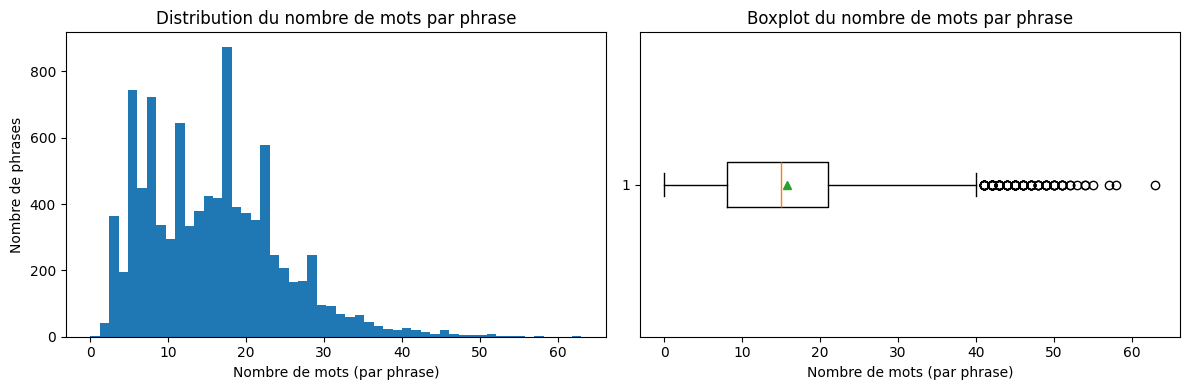

In [152]:
# ------------------------------------------------------------
# 1) Word count par phrase (global)
# ------------------------------------------------------------
x = sent_df_filtered["word_count"].to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme
ax[0].hist(x, bins="auto")
ax[0].set_title("Distribution du nombre de mots par phrase")
ax[0].set_xlabel("Nombre de mots (par phrase)")
ax[0].set_ylabel("Nombre de phrases")

# Boxplot
ax[1].boxplot(x, vert=False, showmeans=True)
ax[1].set_title("Boxplot du nombre de mots par phrase")
ax[1].set_xlabel("Nombre de mots (par phrase)")

plt.tight_layout()
plt.show()

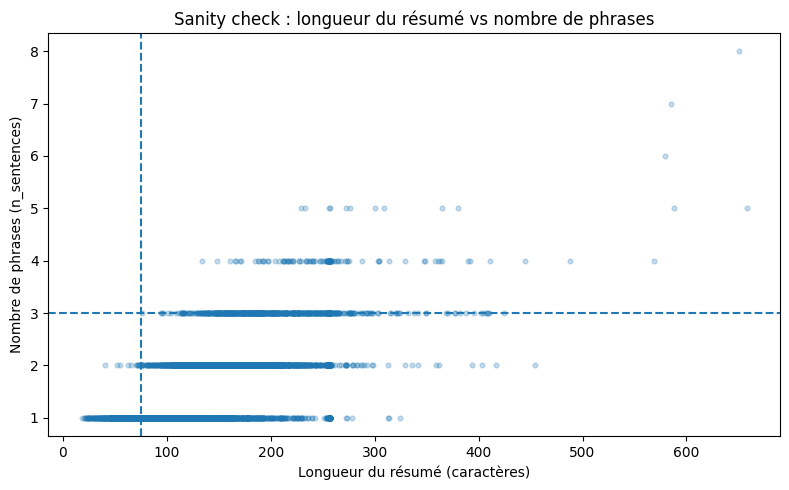

,accident_id,n_sentences,summary_len_chars


In [153]:
# 1) Features par accident
acc_feats = (
    sent_df_filtered.assign(
        summary_len_chars=sent_df["accident_summary"].fillna("").astype(str).str.len()
    )
    .groupby("accident_id", as_index=False)
    .agg(
        n_sentences=("sentence", "size"),
        summary_len_chars=("summary_len_chars", "first"),  # même valeur pour tout l'accident
    )
)

x = acc_feats["summary_len_chars"].to_numpy()
y = acc_feats["n_sentences"].to_numpy()

# 2) Seuils pour repérer les cas suspects (ajuste si tu veux)
x_thr = np.quantile(x, 0.10)   # accidents les + courts (10%)
y_thr = np.quantile(y, 0.90)   # accidents les + segmentés (10%)

suspect = (x <= x_thr) & (y >= y_thr)

# 3) Scatter + zone suspecte
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.scatter(x[~suspect], y[~suspect], alpha=0.25, s=12)
ax.scatter(x[suspect],  y[suspect],  alpha=0.9,  s=18)

ax.axvline(x_thr, linestyle="--")
ax.axhline(y_thr, linestyle="--")

ax.set_title("Sanity check : longueur du résumé vs nombre de phrases")
ax.set_xlabel("Longueur du résumé (caractères)")
ax.set_ylabel("Nombre de phrases (n_sentences)")

plt.tight_layout()
plt.show()

# 4) Liste des accidents suspects (pour inspection)
suspects_df = acc_feats.loc[suspect].sort_values(["summary_len_chars", "n_sentences"], ascending=[True, False])
suspects_df.head(20)

In [154]:
suspects_df 

,accident_id,n_sentences,summary_len_chars


In [155]:
#sent_df_filtered.head()

In [156]:
from itertools import chain

df = sent_df_filtered.copy()
n_recits = df["accident_id"].nunique()
n_unites = len(df)
unites_par_recit = n_unites / n_recits if n_recits else np.nan
longueur_mediane = int(np.median(df["word_count"].values)) if n_unites else 0

tokens_series = df["sentence"].fillna("").astype(str).str.lower().str.findall(word_re)
vocab_size = len(set(chain.from_iterable(tokens_series.tolist())))

n_recits, n_unites, unites_par_recit, longueur_mediane, vocab_size


(5673, 9577, 1.6881720430107527, 15, 6180)

In [157]:
sent_df_filtered["fact_id"] = [i for i in range(1,sent_df_filtered.shape[0]+1)]

In [158]:
sent_df_filtered.to_excel("data/nicollin_sentence_accidents.xlsx", index=False)

In [159]:
sent_df_filtered.to_csv("data/nicollin_sentence_accidents.csv", index=False)